In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [40]:
df = pd.read_csv("advertising.csv")

# Clean column names and remove an extra exported index column
df.columns = df.columns.str.strip()
df = df.loc[:, ~df.columns.str.contains(r"^Unnamed", case=False)]

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)
display(df.head())

Dataset loaded successfully!
Dataset shape: (200, 4)


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [41]:
print("Column names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nStatistical summary:")
display(df.describe())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Column names:
['TV', 'Radio', 'Newspaper', 'Sales']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB

Statistical summary:


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000



Missing values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Duplicate rows: 0


In [42]:
required_columns = ["TV", "Radio", "Newspaper", "Sales"]

missing_columns = [
    col for col in required_columns if col not in df.columns
]

if missing_columns:
    raise ValueError(f"Missing expected columns: {missing_columns}")

# Convert required columns to numeric if necessary
for col in required_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Remove rows with missing required values
df = df.dropna(subset=required_columns)

print("Dataset ready for analysis.")
print("Rows and columns:", df.shape)
print("Missing values:\n", df[required_columns].isnull().sum())

Dataset ready for analysis.
Rows and columns: (200, 4)
Missing values:
 TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


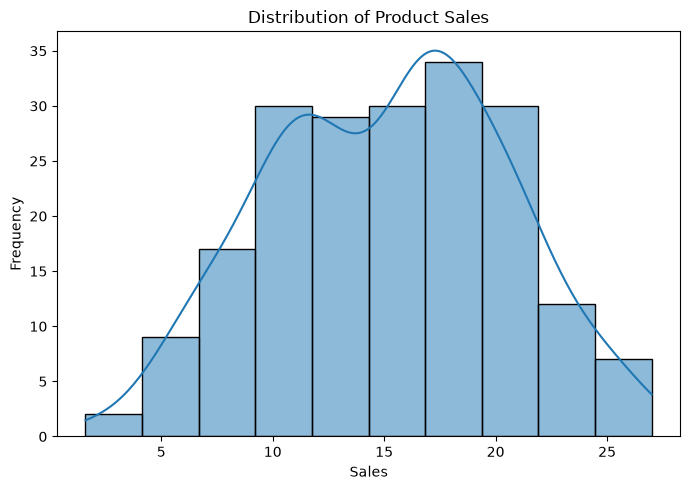

In [43]:
plt.figure(figsize=(7, 5))
sns.histplot(df["Sales"], kde=True)
plt.title("Distribution of Product Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

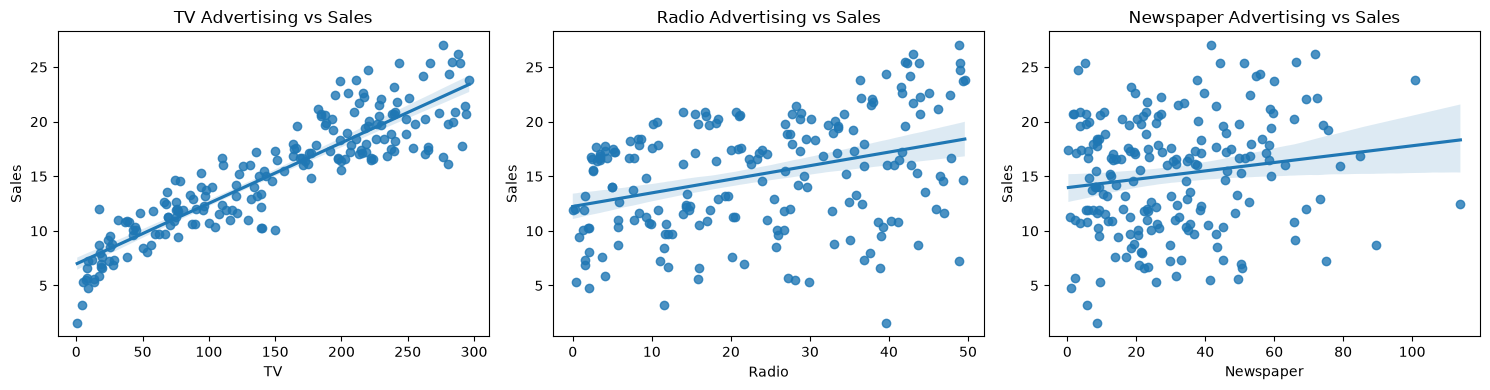

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

channels = ["TV", "Radio", "Newspaper"]

for ax, channel in zip(axes, channels):
    sns.regplot(data=df, x=channel, y="Sales", ax=ax)
    ax.set_title(f"{channel} Advertising vs Sales")

plt.tight_layout()
plt.show()

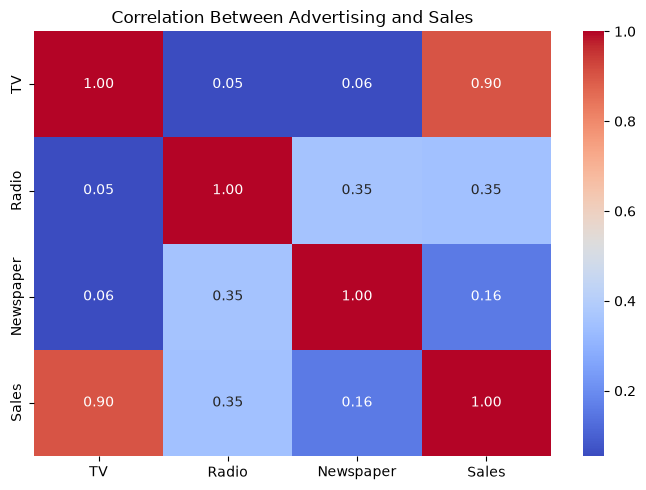

In [45]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    df[["TV", "Radio", "Newspaper", "Sales"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Advertising and Sales")
plt.tight_layout()
plt.show()

In [46]:
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

print("Input features:", X.columns.tolist())
print("Target variable: Sales")
print("Number of observations:", len(df))


Input features: ['TV', 'Radio', 'Newspaper']
Target variable: Sales
Number of observations: 200


In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 160
Testing samples: 40


In [48]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")
print("Intercept:", round(model.intercept_, 4))

Linear Regression model trained successfully!
Intercept: 4.7141


In [49]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

results["Prediction Error"] = (
    results["Actual Sales"] - results["Predicted Sales"]
)

display(results.head(10))

,Actual Sales,Predicted Sales,Prediction Error
0,16.9,17.034772,-0.134772
1,22.4,20.409740,1.990260
2,21.4,23.723989,-2.323989
3,7.3,9.272785,-1.972785
4,24.7,21.682719,3.017281
5,12.6,12.569402,0.030598
6,22.3,21.081195,1.218805
7,8.4,8.690350,-0.290350
8,16.5,17.237013,-0.737013
9,16.1,16.666575,-0.566575


In [50]:
new_budget = pd.DataFrame({
    "TV": [150],
    "Radio": [20],
    "Newspaper": [30]
})

predicted_sales = model.predict(new_budget)[0]

print("Advertising Budget")
print("TV:", 150)
print("Radio:", 20)
print("Newspaper:", 30)

print(f"\nPredicted Sales: {predicted_sales:.3f}")

Advertising Budget
TV: 150
Radio: 20
Newspaper: 30

Predicted Sales: 15.040


In [51]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²): {r2:.4f}")

Mean Absolute Error (MAE): 1.2748
Mean Squared Error (MSE): 2.9078
Root Mean Squared Error (RMSE): 1.7052
R-squared (R²): 0.9059


In [52]:
coefficients = pd.DataFrame({
    "Advertising Medium": X.columns,
    "Coefficient": model.coef_
})

display(
    coefficients.sort_values(
        "Coefficient",
        ascending=False
    )
)

strongest = coefficients.loc[
    coefficients["Coefficient"].idxmax()
]

weakest = coefficients.loc[
    coefficients["Coefficient"].idxmin()
]

print(
    "Largest coefficient:",
    strongest["Advertising Medium"],
    round(strongest["Coefficient"], 4)
)

print(
    "Smallest coefficient:",
    weakest["Advertising Medium"],
    round(weakest["Coefficient"], 4)
)

,Advertising Medium,Coefficient
1,Radio,0.100945
0,TV,0.054509
2,Newspaper,0.004337


Largest coefficient: Radio 0.1009
Smallest coefficient: Newspaper 0.0043


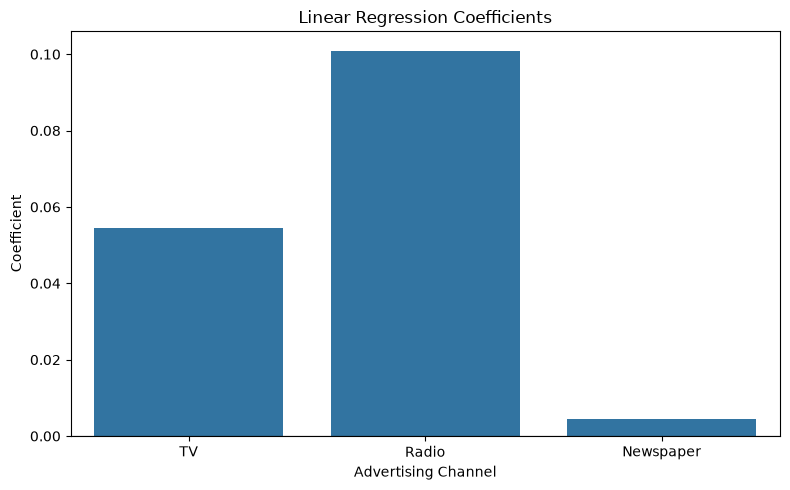

In [53]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=coefficients,
    x="Advertising Medium",
    y="Coefficient"
)

plt.axhline(0, color="black", linewidth=0.8)
plt.title("Linear Regression Coefficients")
plt.ylabel("Coefficient")
plt.xlabel("Advertising Channel")
plt.tight_layout()
plt.show()

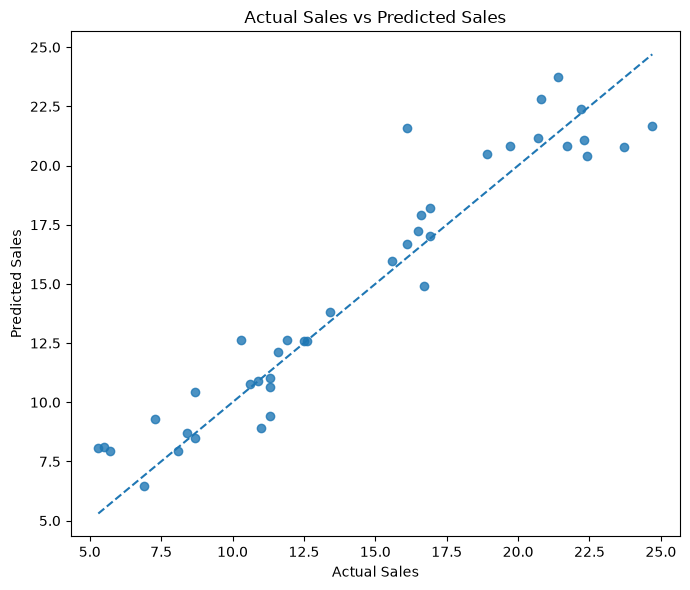

In [54]:
plt.figure(figsize=(7, 6))

plt.scatter(y_test, y_pred, alpha=0.8)

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual Sales vs Predicted Sales")
plt.tight_layout()
plt.show()

In [55]:
comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

display(comparison.head(15))

,Actual Sales,Predicted Sales
0,16.9,17.034772
1,22.4,20.409740
2,21.4,23.723989
3,7.3,9.272785
4,24.7,21.682719
5,12.6,12.569402
6,22.3,21.081195
7,8.4,8.690350
8,16.5,17.237013
9,16.1,16.666575
